#### Assignment 3 - Transformer Models — Attention-Based Architectures
**Mahshid Bargahi**


In this notebook, we fine-tune a pretrained **DistilBERT** model on the BBC News dataset and compare its performance with recurrent architectures (RNN, LSTM, and GRU).

The objective is to investigate whether self-attention based models can better capture contextual information and long-range dependencies in text classification tasks.

## Import Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import accelerate
import tensorflow as tf

import warnings
warnings.filterwarnings("ignore")

sns.set(color_codes=True)

## Loading the dataset

In [17]:
data = pd.read_csv(r"D:\sharif\ADS\assignments\assignment3\Transformer Models\bbc-text.csv")
data.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


## Getting some insight frome data

In [3]:
data.shape

(2225, 2)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  2225 non-null   object
 1   text      2225 non-null   object
dtypes: object(2)
memory usage: 34.9+ KB


In [6]:
data.isnull().sum()

category    0
text        0
dtype: int64

There is'nt any missing value.

In [7]:
data.duplicated().sum()

np.int64(99)

There is'nt any duplicated samples.

In [8]:
data['category'].value_counts()

category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

Category classes have a close number of samples. Then dataset is balanced.

## Preprocessing

### Encoding categories labels

In [18]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

data["label"] = encoder.fit_transform(data["category"])

num_labels = len(encoder.classes_)
print(encoder.classes_)

['business' 'entertainment' 'politics' 'sport' 'tech']


## Train/Test Split

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data['text'], data['label'],
    test_size=0.2,
    random_state=42,
    stratify=data["label"])  # preserves class proportions

print(X_train.shape)
print(X_test.shape)

(1780,)
(445,)


## Install and Import transformar libraries

In [14]:
!pip install -i https://pypi.tuna.tsinghua.edu.cn/simple transformers datasets scikit-learn

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ---------------------------------------- 0.0/555.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/555.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/555.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/555.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/555.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/555.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/555.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/555.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/555.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/555.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/555.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/555.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/555.1 kB ? et

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\kavoshrayan\\AppData\\Local\\Temp\\pip-unpack-qpc8mnuo\\pyarrow-24.0.0-cp313-cp313-win_amd64.whl'
Consider using the `--user` option or check the permissions.



In [21]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

## Tokenization

In Transformer models such as DistilBERT, raw text cannot be used directly. Instead, it must be converted into numerical format using a pretrained tokenizer.

The tokenizer performs the following steps:

- Tokenization: Splits text into subword units (tokens) based on the model’s vocabulary.
- Conversion to IDs: Each token is mapped to a unique integer ID.
- Padding: Sequences are padded so all inputs in a batch have the same length.
- Truncation: Long texts are shortened to a maximum length (128 tokens).
- Attention Mask: A mask is created to distinguish real tokens (1) from padding (0).


Unlike traditional NLP pipelines (e.g., RNNs), no manual preprocessing such as stopword removal or stemming is required, since pretrained Transformers are trained on raw natural language.

In [22]:
# DistilBERT tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

train_encodings = tokenizer(X_train.tolist(), truncation=True, padding=True, max_length=128)

test_encodings = tokenizer(X_test.tolist(), truncation=True, padding=True, max_length=128)

## Load DistilBERT

Since BBC News classification is a single-label multiclass problem, the model uses Cross-Entropy Loss. When labels are provided to AutoModelForSequenceClassification, Hugging Face automatically computes the loss internally during training, eliminating the need to define the loss function manually.

In [23]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels  # number of BBC categories (for classification in dense layer)
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Creating Dataset Class

Because PyTorch (and HuggingFace Trainer) cannot directly train on raw Python lists or pandas dataframes we implement a custom PyTorch Dataset to convert tokenized inputs into tensor format and enable batch processing. This step ensures compatibility with the HuggingFace Trainer API, which requires a standardized dataset interface.

A custom Dataset object was created to combine tokenized inputs and labels into a format compatible with the PyTorch training pipeline.

In [24]:
class BBCDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

### Build Train and Test datasets

In [25]:
train_dataset = BBCDataset(train_encodings, y_train.tolist())
test_dataset = BBCDataset(test_encodings, y_test.tolist())

# returns a single training sample containing input IDs, attention masks, and the corresponding label
train_dataset.__getitem__(0)

{'input_ids': tensor([  101,  3745, 12992,  2005, 13552,  1011,  2718, 17975,  1996,  2604,
          1997,  2796, 22453, 17975,  2038,  3530,  1037,  3745,  4965,  1011,
          2067,  2000,  4675,  1996,  3896,  1997,  1037,  2373,  5998,  1999,
          1996,  9756,  2155,  1012,  1996,  4965,  1011,  2067,  2003,  1037,
          3377,  2005,  3472, 14163,  9681,  2232,  2572,  8193,  2072,  3005,
          2801,  2009,  2001,  1012,  2010,  2567,  2019,  4014,  1996,  3580,
          1011,  3472,  2056,  2018,  2025,  2042, 17535,  1998,  2008,  1996,
          4965,  1011,  2067,  2001,  3294, 15884,  1998, 14203,  1012,  1996,
          2604,  8069,  1996,  2693,  2097,  7901,  1037,  2410,  1003,  2991,
          1999, 17975,  1055,  6661,  2144,  1996, 13552,  2150,  2270,  2197,
          3204,  1012,  1996,  2194,  2038,  2042, 25312,  6593,  6313,  2144,
          3910, 28144,  4313, 12083, 10932,  2572,  8193,  2072,  2351,  1999,
          2526,  2975,  2053,  2097,  1

### Set Training arguments (Fine-Tuning)

TrainingArguments defines the configuration for the fine-tuning process, including batching, evaluation strategy, regularization, logging, and model saving behavior.

Fine-tuning adapts a pretrained DistilBERT model to the BBC News classification task by continuing training on the labeled dataset and updating the model weights through backpropagation.

In [26]:
training_args = TrainingArguments(
    output_dir="./results",   # the directory where model checkpoints, logs, and outputs will be saved during training
    eval_strategy="epoch",    # evaluation is performed after each training epoch
    save_strategy="epoch",    # saves the model checkpoint after each epoch
    num_train_epochs=2,       # number of times the model will go through the entire training dataset
    per_device_train_batch_size=8,      # number of training samples are processed at once per device (GPU/CPU) during training
    per_device_eval_batch_size=8,       # number of samples are processed at once during evaluation
    weight_decay=0.01,        # apply L2 regularization to reduce overfitting
    logging_steps=50          # controls how often training progress (loss, metrics) is printed during training (every 50 steps)
)

### Compute metrics function

The compute_metrics function evaluates the model by comparing predicted labels with the true labels. It computes Accuracy, which measures the percentage of correct predictions, and the weighted F1-score, which balances precision and recall across all classes.
 
These metrics are used to monitor model performance during evaluation.

In [27]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
    labels = pred.label_ids

    preds = pred.predictions.argmax(-1)

    acc = accuracy_score(labels, preds)

    f1 = f1_score(labels, preds, average="weighted")

    return {
        "accuracy": acc,
        "f1": f1
    }

### Train and Evaluate the model


The Trainer object combines the model, training configuration, datasets, and evaluation metrics into a single training pipeline. 

Calling trainer.train() fine-tunes the pretrained DistilBERT model on the BBC News dataset by performing forward passes, computing loss, updating model weights through backpropagation, and evaluating performance after each epoch.

In [28]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# train the model
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.097292,0.212978,0.950562,0.950084
2,0.060283,0.105206,0.975281,0.975380


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=446, training_loss=0.1851953856079033, metrics={'train_runtime': 1652.1111, 'train_samples_per_second': 2.155, 'train_steps_per_second': 0.27, 'total_flos': 117902292326400.0, 'train_loss': 0.1851953856079033, 'epoch': 2.0})

In [29]:
# evaluate the model
results = trainer.evaluate()

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.060283,0.105206,2,0.975281,0.975380


In [35]:
transformer_result = pd.DataFrame([{
    "Model": "DistilBERT",
    "Test Accuracy": results["eval_accuracy"],
    "F1 Score": results["eval_f1"],
    "Test Loss": results["eval_loss"]
}])

transformer_result

,Model,Test Accuracy,F1 Score,Test Loss
0,DistilBERT,0.975281,0.97538,0.105206


## Compare Transformer performance with RNN/LSTM

In [36]:
# load RNN models results from RNNs notebook
rnn_results = pd.read_csv(r"D:\sharif\ADS\assignments\assignment3\RNN\rnn_results.csv")

rnn_results["Model"] = ["Vanilla RNN", "LSTM", "GRU"]

comparison_df = pd.concat(
    [rnn_results, transformer_result],
    ignore_index=True
)
comparison_df

,Test Accuracy,Test Loss,F1 Score,Model
0,0.469663,1.268375,0.465910,Vanilla RNN
1,0.907865,0.290155,0.908398,LSTM
2,0.566292,1.114638,0.516283,GRU
3,0.975281,0.105206,0.975380,DistilBERT


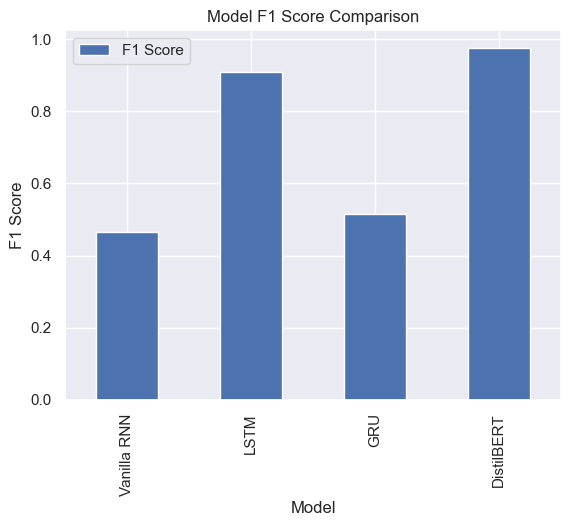

In [39]:
comparison_df.plot(
    x="Model",
    y="F1 Score",
    kind="bar"
)

plt.title("Model F1 Score Comparison")
plt.ylabel("F1 Score")
plt.show()

- The experimental results clearly show that Transformer-based models significantly outperform traditional RNN-based architectures.
- Vanilla RNN suffers from poor performance due to vanishing gradient issues, LSTM improves performance by capturing long-term dependencies.
- GRU shows moderate performance but does not outperform LSTM in this setup.

- The DistilBERT Transformer achieves the best results in terms of accuracy, loss, and F1-score, demonstrating the effectiveness of self-attention mechanisms and pretrained contextual representations for text classification tasks.

- The superior performance of Transformers comes at the cost of higher computational complexity and training time compared to RNN-based models.

# Discussion Questions

### 1.**The main advantages and disadvantages of Transformer-based models**

Advantages:

- Capture long-range dependencies effectively.
- Highly parallelizable during training.
- Achieve state-of-the-art performance on many NLP and vision tasks.
- Scale well with larger datasets and model sizes.

Disadvantages:

- Require large amounts of data and compute.
- High memory consumption, especially for long sequences.
- More expensive to train and deploy than simpler models(Like RNNs).


### 2.**Why do they scale well with data and model size?**
RNNs/LSTMs scale poorly with model size because the sequential recurrence creates a computational bottleneck and leads to vanishing/exploding gradients and they have a strong inductive bias of sequential order.

Transformers scale well because they replace strong, built-in assumptions about data structure (like sequential order in RNNs) with a flexible, parallelizable, and data-driven **attention mechanism**. This weak inductive bias allows them to efficiently utilize massive amounts of parameters and data, leading to predictable power a property no previous architecture demonstrated at the same scale.

Actually, Transformer's architecture is highly parallelizable on modern hardware (GPUs/TPUs) and self-attention allows learning rich relationships between tokens. And also performance often improves predictably as data and model size increase(the large model over small data will overfit)


### 3.**Why do they often require large computational resources compared to simpler models?**

Because they contain a huge number of parameters and use the self-attention mechanism, which compares every token with every other token in a sequence(resulting in O(n²) time). As the model size and sequence length increase, the amount of computation and memory needed grows significantly. Training these models therefore requires powerful hardware, large amounts of memory, and considerable processing time.

Also training requires large datasets, extensive memory, and powerful hardware.


### 4.**What is self-attention, and what problem does it solve?**

Self-attention is a mechanism that computes a weighted relationship between every pair of elements(tokens) in a sequence, allowing each element to directly aggregate information from all others(understanding its meaning).

 It solves the fundamental problem of long-range dependency that plagued RNNs (forgetting), while also enabling full parallelism. This ability to create direct, dynamic, and distance-free connections makes Transformers so powerful for sequence data.

Foe example:

"The cat ate the mouse because it was hungry."

Self-attention helps determine whether it refers to cat or mouse by considering the entire sentence.


### 5.**Why can attention model long-range dependencies more effectively than simple RNNs?**

In RNNs, information must pass through many intermediate hidden states, that causing **Vanishing gradients** and **Loss of long-term information**.

But in self-attention any token can directly attend to any other token in a single step (allows each word to look directly at any other word). Then path length between distant words is effectively 1. This makes learning long-range relationships much easier.

### 6.**What is multi-head attention, and why does it help?**

Multi-head attention uses several attention mechanisms (heads) in parallel.

Each head can focus on different aspects of the sequence, such as Grammar , Semantic meaning , Word dependencie and Entity relationships.

Then concatenates the results. It helps because a single attention head can only capture one weighted relationship pattern at a time, forcing different types of information (syntactic, semantic, positional) to compete. Multi-head attention allows the model to simultaneously attend to different things using different heads

This allows the model to learn richer and more diverse representations than a single attention.


### 7.**What is the role of positional encoding?**

Self-attention alone does not know the order of tokens.

Positional encoding adds information about each token's position in the sequence so the model can understand word order.

For example without positional encoding:

"The cat ate the mouse"

and

"The mouse ate the cat"

would appear as the same set of tokens.

Positional encodings allow Transformers to distinguish between these different sequences and understand syntax, word order, and temporal relationships.
